# Convert CML data

> This module provides functions to convert CML xarray data into other formats such as GeoDataFrames.

In [ ]:
#| default_exp data.convert

In [ ]:
#| export
#| hide
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import LineString

In [ ]:
#| hide
# Libraries for testing and visualization
import matplotlib.pyplot as plt
from raincell import open_cml_sample
from nbdev.showdoc import *

In [ ]:
cml = open_cml_sample()

## Convert sublinks to GeoDataFrame

When a CML has multiple sublinks, they share the same geometry. To visualize them
distinctly on a map, we offset each sublink **perpendicularly** to the link direction
using the normal vector of the line. Sublinks alternate on each side of the original
link, spreading outward.

:::{.callout-warning}
The perpendicular offset is applied in degrees of longitude/latitude. Near the equator, 1° of longitude ≈ 1° of latitude ≈ 111 km, so the default offset of `2e-4°` ≈ 20 m. At higher latitudes, degrees of longitude shrink (by a factor of `cos(latitude)`), so the same offset in degrees will correspond to a different physical distance.
:::

In [ ]:
#| hide
cml = cml.sel(cml_id=["4.056847N-9.738556E"]).isel(time=slice(None, 24))

In [ ]:
#| hide
cml_meta = cml.coords.to_dataset()
cml_meta = cml_meta.drop_vars("time")
meta_dims = list(cml_meta.dims)
meta_dims

['cml_id', 'sublink_id']

In [ ]:
#| hide
cml_df = cml_meta.to_dataframe().reset_index()
cml_df = cml_df.drop_duplicates()
cml_df.head(3)

,cml_id,sublink_id,frequency,site_0_lat,site_0_lon,site_1_lat,site_1_lon,transmitter,length
0,4.056847N-9.738556E,0_0,12765.0,4.060028,9.726194,4.053667,9.750917,0.0,2834.0
1,4.056847N-9.738556E,0_1,13031.0,4.060028,9.726194,4.053667,9.750917,1.0,2834.0
2,4.056847N-9.738556E,1_0,12765.0,4.060028,9.726194,4.053667,9.750917,0.0,2834.0


#| hide
We will drop any sublink with missing required metadata based on the OpenSense v2 standard

In [ ]:
cml_df = cml_df.dropna(subset=["site_0_lat", "site_0_lon", "site_1_lat", "site_1_lon", "frequency"], how="any")
cml_df.head(2)

,cml_id,sublink_id,frequency,site_0_lat,site_0_lon,site_1_lat,site_1_lon,transmitter,length
0,4.056847N-9.738556E,0_0,12765.0,4.060028,9.726194,4.053667,9.750917,0.0,2834.0
1,4.056847N-9.738556E,0_1,13031.0,4.060028,9.726194,4.053667,9.750917,1.0,2834.0


We define the direction vector $\mathbf{v}$ for each sublink as the difference in coordinates: $$\mathbf{v} = (\Delta \text{lon}, \Delta \text{lat}) = (\text{lon}_1 - \text{lon}_0, \text{lat}_1 - \text{lat}_0)$$

In [ ]:
#| hide
v = pd.DataFrame({
    "x": cml_df.site_1_lon - cml_df.site_0_lon,
    "y": cml_df.site_1_lat - cml_df.site_0_lat,
})

As you move away from the equator, the distance represented by one degree of longitude shrinks. To make our direction vector $\mathbf{v}$ meaningful in a local Cartesian-like space, we need to scale the longitudinal component ($\Delta \text{lon}$) by the cosine of the latitude:

$$\Delta \text{lon}_{\text{scaled}} = \Delta \text{lon} \cdot \cos(\phi)$$

where $\phi$ is the latitude (converted to radians in your code). This ensures that a "step" in the x-direction is physically comparable to a "step" in the y-direction, regardless of where the link is located on Earth.

In [ ]:
#| hide
phi_rad = np.deg2rad(cml_df.site_1_lat - cml_df.site_0_lat)
v.x *= np.cos(phi_rad)

To make the sublinks visually distinct, we calculate a normal vector ($\mathbf{n}$) that is perpendicular to the link's direction vector ($\mathbf{v}$).

If our direction vector is $\mathbf{v} = (v_x, v_y)$, we can find a perpendicular vector by swapping the components and negating one: $$\mathbf{n} = (-v_y, v_x)$$

You can check that this is perpendicular because the dot product $\mathbf{v} \cdot \mathbf{n} = v_x(-v_y) + v_y(v_x) = 0$.

However, this normal vector $\mathbf{n}$ might have any length. To control the offset distance precisely, we need a unit normal vector ($\mathbf{\hat{n}}$) with a length of 1: $$\mathbf{\hat{n}} = \frac{\mathbf{n}}{||\mathbf{n}||} = \frac{(-v_y, v_x)}{\sqrt{(-v_y)^2 + v_x^2}}$$

In [ ]:
#| hide
n = pd.DataFrame({"x": -v.y, "y": v.x})
norm = (1 / np.sqrt(n.x**2 + n.y**2)).values.reshape(-1, 1)
n *= norm
n.head(2)

,x,y
0,0.249175,0.968458
1,0.249175,0.968458


Because we calculated the normal vector $\mathbf{n}$ in a Cartesian-like space where the x-axis was compressed by $\cos(\phi)$, its longitudinal component $n_x$ is currently in those scaled units. To use this as a coordinate offset in degrees of longitude, we must "unscale" it:

$$n_{x, \text{degrees}} = \frac{n_{x, \text{scaled}}}{\cos(\phi)}$$

This brings the vector component back to the original degree units so it can be added directly to the latitude and longitude coordinates.

In [ ]:
#| hide
n.x /= np.cos(phi_rad)
n.head(2)

,x,y
0,0.249175,0.968458
1,0.249175,0.968458


To calculate the offset for each sublink, we will determine a magnitude based on the sublink's position relative to the main link:

1.  **Relative Numbering**: Each sublink is assigned an index $i$.
2.  **Alternating Direction**: We assign a sign $s \in \{-1, 1\}$ to ensure sublinks are distributed on both sides of the main link path:
    $$s = (i \pmod 2) \cdot 2 - 1$$
3.  **Magnitude**: The total offset $M$ is calculated by multiplying the base offset $O$ (approx. 20m) by the pairing factor $\lfloor i/2 \rfloor$ and the alternating sign:
    $$M = O \cdot \lfloor i/2 \rfloor \cdot s$$

This creates a spreading effect where sublinks are placed at increasing distances from the center, alternating in direction for better visualization. The center of the link is left empty to be able to plot the link.

In [ ]:
#| hide
offset = 2e-4 # ~ 20m in the equator
sblnk_rel_num = cml_df.groupby("cml_id").cumcount() + 2
sign = (sblnk_rel_num % 2) * 2 - 1
magnitude = offset * (sblnk_rel_num // 2) * sign
sign, magnitude

(0   -1
 1    1
 2   -1
 3    1
 4   -1
 5    1
 dtype: int64,
 0   -0.0002
 1    0.0002
 2   -0.0004
 3    0.0004
 4   -0.0006
 5    0.0006
 dtype: float64)

Finally, we shift the coordinates of both the start point ($P_0$) and the end point ($P_1$) of the sublink by the calculated magnitude ($M$) along the unit normal vector ($\mathbf{\hat{n}}$) to obtain the new geometry coordinates:

$$P_{0, \text{new}} = P_0 + M \cdot \mathbf{\hat{n}}$$
$$P_{1, \text{new}} = P_1 + M \cdot \mathbf{\hat{n}}$$

:::{.callout-warning}
The offset is applied only to the coordinates of the lines that form the GeoDataFrame geometry, not to the original site coordinate columns stored in the metadata. This distinction is crucial to preserve the original data, ensuring that you can easily perform backward conversion from a GeoDataFrame back to the original xarray format later.
:::

In [ ]:
#| hide
s0_lns = cml_df.site_0_lon + magnitude * n.x
s1_lns = cml_df.site_1_lon + magnitude * n.x
s0_lts = cml_df.site_0_lat + magnitude * n.y
s1_lts = cml_df.site_1_lat + magnitude * n.y

<Axes: >

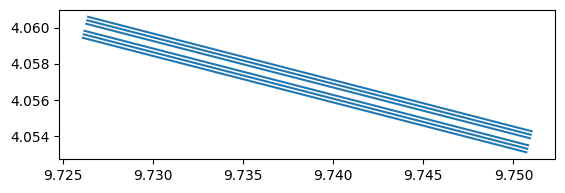

In [ ]:
#| hide
geom = [LineString([(s0_ln, s0_lt), (s1_ln, s1_lt)]) for s0_ln, s1_ln, s0_lt, s1_lt  in zip(s0_lns, s1_lns, s0_lts, s1_lts)]
gdf = gpd.GeoDataFrame(cml_df, geometry=geom, crs="EPSG:4326")
gdf.plot()

<Axes: >

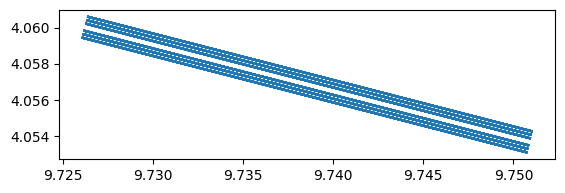

In [ ]:
#| hide
gdf.set_index(meta_dims, inplace=True)
cml_data = cml.drop_vars([c for c in list(cml.coords) if c not in cml.dims])
gdf = gdf.join(cml_data.to_dataframe())
gdf.plot()

In [ ]:
#| export
def convert_sublinks_to_gdf(
    cml: xr.DataArray | xr.Dataset, # CML data
    only_meta: bool = True, # The GeoDataFrame will only contain metadata
    offset: float = 2e-4, # Perpendicular offset in degrees (2e-4 ~ 20m in the equator) in order to avoid overlap in visualization
) -> gpd.GeoDataFrame:
    """Convert CML to a GeoDataFrame assuming EPSG:4326 projection"""
    cml_meta = cml.coords.to_dataset()
    cml_meta = cml_meta.drop_vars("time")
    meta_dims = list(cml_meta.dims)
    cml_df = cml_meta.to_dataframe().reset_index()
    cml_df = cml_df.drop_duplicates()
    cml_df = cml_df.dropna(subset=["site_0_lat", "site_0_lon", "site_1_lat", "site_1_lon", "frequency"], how="any")

    v = pd.DataFrame({
        "x": cml_df.site_1_lon - cml_df.site_0_lon,
        "y": cml_df.site_1_lat - cml_df.site_0_lat,
    })
    phi_rad = np.deg2rad(cml_df.site_1_lat - cml_df.site_0_lat)
    v.x *= np.cos(phi_rad)


    n = pd.DataFrame({"x": -v.y, "y": v.x})
    norm = (1 / np.sqrt(n.x**2 + n.y**2)).values.reshape(-1, 1)
    n *= norm
    n.x /= np.cos(phi_rad)
    

    sblnk_rel_num = cml_df.groupby("cml_id").cumcount() + 2
    sign = (sblnk_rel_num % 2) * 2 - 1
    magnitude = offset * (sblnk_rel_num // 2) * sign

    s0_lns = cml_df.site_0_lon + magnitude * n.x
    s1_lns = cml_df.site_1_lon + magnitude * n.x
    s0_lts = cml_df.site_0_lat + magnitude * n.y
    s1_lts = cml_df.site_1_lat + magnitude * n.y

    geom = [LineString([(s0_ln, s0_lt), (s1_ln, s1_lt)]) for s0_ln, s1_ln, s0_lt, s1_lt  in zip(s0_lns, s1_lns, s0_lts, s1_lts)]
    gdf = gpd.GeoDataFrame(cml_df, geometry=geom, crs="EPSG:4326")
    if only_meta:
        return gdf
    else:
        gdf.set_index(meta_dims, inplace=True)
        cml_data = cml.drop_vars([c for c in list(cml.coords) if c not in cml.dims])
        gdf = gdf.join(cml_data.to_dataframe())
        return gdf.reset_index()


<Axes: >

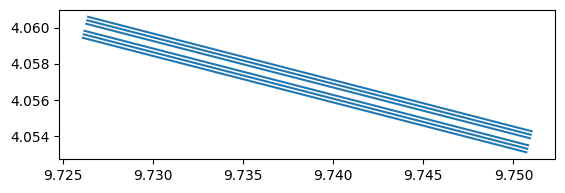

In [ ]:
convert_sublinks_to_gdf(cml).plot()

In [ ]:
convert_sublinks_to_gdf(cml, only_meta=False).head(2)

,cml_id,sublink_id,time,frequency,site_0_lat,site_0_lon,site_1_lat,site_1_lon,transmitter,length,geometry,rsl_avg,tsl_avg,rsl_min,tsl_min,rsl_max,tsl_max
0,4.056847N-9.738556E,0_0,2019-07-01 00:05:00,12765.0,4.060028,9.726194,4.053667,9.750917,0.0,2834.0,"LINESTRING (9.72614 4.05983, 9.75087 4.05347)",-43.3,13.0,-43.4,13.0,-43.1,13.0
1,4.056847N-9.738556E,0_0,2019-07-01 00:20:00,12765.0,4.060028,9.726194,4.053667,9.750917,0.0,2834.0,"LINESTRING (9.72614 4.05983, 9.75087 4.05347)",-43.2,13.0,-43.3,13.0,-43.1,13.0


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()